# **Quant @ Illinois Spring 2025**
Software Engineering Application Question: **[Reachable](https://docs.google.com/document/d/1tTnoU4P9hcxWF6sbjeoyJg3POr65hvXTXERwkFYx1GE/edit?tab=t.0)**

Find the sum of the lengths of all the unreachable sides of n triangles in the first quadrant.

## Solved using **Monte Carlo sampling**.

# 1. Setup

To solve this problem, we're going to start by setting up a foundation to work on. This means being able to plot our triangles. Largely, this is pretty self explanatory code. We're using `numpy` and `matplotlib` to graph and connect a set of 3 vertices which form our triangle.



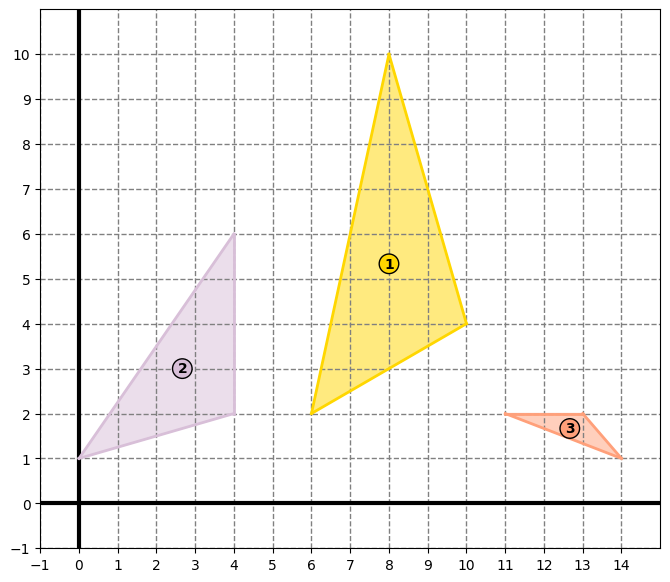

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import random

class Triangle:
    def __init__(self, vertices, triangle_number):
        self.vertices = vertices
        self.points = []
        self.rays = []
        self.line_segments = []
        self.reachable_sides = []
        self.perimeter = None
        self.triangle_number = triangle_number

    def plot(self):
        colors = [
            "lightcoral",
            "lightsalmon",
            "sandybrown",
            "gold",
            "darkseagreen",
            "turquoise",
            "skyblue",
            "mediumpurple",
            "thistle",
        ]
        color = random.choice(colors)
        a, b, c = (
            np.array(self.vertices[0]),
            np.array(self.vertices[1]),
            np.array(self.vertices[2]),
        )
        t = np.linspace(0, 1, 100)
        line_AB = np.outer(1 - t, a) + np.outer(t, b)
        line_BC = np.outer(1 - t, b) + np.outer(t, c)
        line_CA = np.outer(1 - t, c) + np.outer(t, a)
        plt.fill([a[0], b[0], c[0]], [a[1], b[1], c[1]], color=color, alpha=0.5)
        plt.plot(line_AB[:, 0], line_AB[:, 1], color=color, linewidth=2)
        plt.plot(line_BC[:, 0], line_BC[:, 1], color=color, linewidth=2)
        plt.plot(line_CA[:, 0], line_CA[:, 1], color=color, linewidth=2)

        centroid = np.mean(self.vertices, axis=0)

        plt.text(
            centroid[0],
            centroid[1],
            str(self.triangle_number),
            color="black",
            fontsize=10,
            fontweight="bold",
            ha="center",
            va="center",
            bbox=dict(boxstyle="circle,pad=0.2", facecolor=color, edgecolor="black"),
            zorder=6,
        )

def graph(*commands):
    plt.figure(figsize=(8, 7))
    plt.axhline(0, color="black", linewidth=3)
    plt.axvline(0, color="black", linewidth=3)
    plt.grid(color="gray", linestyle="--", linewidth=1)
    plt.xticks(np.arange(custom_axis[0], custom_axis[1], 1))
    plt.yticks(np.arange(custom_axis[2], custom_axis[3], 1))
    plt.axis(custom_axis)
    for func in commands:
        func()
    plt.show()

custom_axis = (-1, 15, -1, 11)

triangles = [
              Triangle([[8, 10], [10, 4], [6, 2]], 1),
              Triangle([[4, 6], [4, 2], [0, 1]], 2),
              Triangle([[13, 2], [14, 1], [11, 2]], 3)
            ]

graph(
  lambda: [triangle.plot() for triangle in triangles],
)

Let's also setup some other code which will come in handy later.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import random

PI = np.pi
POINT_SIZE = 10


class Ray:
    def __init__(self, start, end, line_segment):
        self.start = start
        self.end = end
        self.color = "limegreen"
        self.line_segment = line_segment

    def lies_on(self, segment):
        return (
            segment[0] == self.line_segment[0] and segment[1] == self.line_segment[1]
        ) or (segment[0] == self.line_segment[1] and segment[1] == self.line_segment[0])

    def intersects_with(self, segment):
        return segment_intersection([self.start, self.end], segment)

    def plot(self):
        plt.arrow(
            self.start[0],
            self.start[1],
            self.end[0] - self.start[0],
            self.end[1] - self.start[1],
            head_width=0.2,
            head_length=0.2,
            fc=self.color,
            ec=self.color,
            linewidth=1 / NUM_POINTS,
            zorder=4,
        )


class Triangle:
    def __init__(self, vertices, triangle_number):
        self.vertices = vertices
        self.points = []
        self.rays = []
        self.line_segments = []
        self.reachable_sides = []
        self.perimeter = None
        self.triangle_number = triangle_number

        self.get_line_segments()
        self.get_perimeter()

    def get_line_segments(self):
        for i in range(len(self.vertices)):
            segment = [self.vertices[i], self.vertices[(i + 1) % len(self.vertices)]]
            self.line_segments.append(segment)
            all_segments.append(segment)

    def get_perimeter(self):
        perimeter = 0
        for segment in self.line_segments:
            perimeter += np.linalg.norm(np.array(segment[0]) - np.array(segment[1]))
        self.perimeter = perimeter

    def plot(self):
        colors = [
            "lightcoral",
            "lightsalmon",
            "sandybrown",
            "gold",
            "darkseagreen",
            "turquoise",
            "skyblue",
            "mediumpurple",
            "thistle",
        ]
        color = random.choice(colors)
        a, b, c = (
            np.array(self.vertices[0]),
            np.array(self.vertices[1]),
            np.array(self.vertices[2]),
        )
        t = np.linspace(0, 1, 100)
        line_AB = np.outer(1 - t, a) + np.outer(t, b)
        line_BC = np.outer(1 - t, b) + np.outer(t, c)
        line_CA = np.outer(1 - t, c) + np.outer(t, a)
        plt.fill([a[0], b[0], c[0]], [a[1], b[1], c[1]], color=color, alpha=0.5)
        plt.plot(line_AB[:, 0], line_AB[:, 1], color=color, linewidth=2)
        plt.plot(line_BC[:, 0], line_BC[:, 1], color=color, linewidth=2)
        plt.plot(line_CA[:, 0], line_CA[:, 1], color=color, linewidth=2)

        centroid = np.mean(self.vertices, axis=0)

        plt.text(
            centroid[0],
            centroid[1],
            str(self.triangle_number),
            color="black",
            fontsize=10,
            fontweight="bold",
            ha="center",
            va="center",
            bbox=dict(boxstyle="circle,pad=0.2", facecolor=color, edgecolor="black"),
            zorder=6,
        )


    def sample_points(self):
        for i in range(len(self.vertices)):
            start = np.array(self.vertices[i])
            end = np.array(self.vertices[(i + 1) % len(self.vertices)])
            t_values = np.random.uniform(0, 1, NUM_POINTS)
            self.points.extend([(1 - t) * start + t * end for t in t_values])

    def plot_points(self):
        for point in self.points:
            plt.scatter(point[0], point[1], color="black", s=POINT_SIZE, zorder=5)

    def generate_rays(self):
        for center in self.points:
            associated_segment = None
            for segment in self.line_segments:
                A, B = np.array(segment[0]), np.array(segment[1])
                AB = B - A
                AC = np.array(center) - A
                cross_product = np.cross(AB, AC)
                if np.isclose(cross_product, 0):
                    t = np.dot(AC, AB) / np.dot(AB, AB)
                    if 0 <= t <= 1:
                        associated_segment = segment
                        break

            angle_spacing = np.pi / NUM_RAYS
            angles = np.linspace(-np.pi, -2 * np.pi, NUM_RAYS, endpoint=False)
            rotation_angle = 180 - (angle_spacing / np.pi) * 180 / 2
            angles += np.radians(rotation_angle)

            for angle in angles:
                direction = np.array([np.cos(angle), np.sin(angle)])
                if direction[1] != 0:
                    if associated_segment[0][1] != associated_segment[1][1]:
                        t = -center[1] / direction[1]
                        x_intersect = center[0] + t * direction[0]
                        end_point = [x_intersect, 0]
                        ray = Ray(center.tolist(), end_point, associated_segment)
                        self.rays.append(ray)

    def plot_rays(self):
        for ray in self.rays:
            ray.plot()

def graph(*commands):
    plt.figure(figsize=(8, 7))
    plt.axhline(0, color="black", linewidth=3)
    plt.axvline(0, color="black", linewidth=3)
    plt.grid(color="gray", linestyle="--", linewidth=1)
    plt.xticks(np.arange(custom_axis[0], custom_axis[1], 1))
    plt.yticks(np.arange(custom_axis[2], custom_axis[3], 1))
    plt.axis(custom_axis)
    for func in commands:
        func()
    plt.show()

# 2. Solving

Now, we need to find a way to efficiently find all the 'reachable' (or, conversely, the 'unreachable') sides of each triangle. To do this, we'll use a statistical approach--specifically, we'll be using **Monte Carlo sampling** (MCS for short).

MCS will allow us to quickly determine the validity of different path possibilities using metaheuristics. Essentially, we'll randomly pick points along the sides of the triangles and see if its possible to draw a straight path from the side to the x-axis using an approach similar to a **depth-first search**. This is much faster than testing every single possible path for every single possible point on all the different lines (1), and with enough sampling, will prove to be extremely accurate. Below you can see the code which will allow us to randomly sample points along a given side (line segment).

(1) Depending on the degree of accuracy, attempting to sample every path for every point could be O(n²) as n approaches infinity.


In [ ]:
def sample_points(self):
    for i in range(len(self.vertices)):
        start = np.array(self.vertices[i])
        end = np.array(self.vertices[(i + 1) % len(self.vertices)])
        t_values = np.random.uniform(0, 1, NUM_POINTS)
        self.points.extend([(1 - t) * start + t * end for t in t_values])

def plot_points(self):
    for point in self.points:
        plt.scatter(point[0], point[1], color="black", s=POINT_SIZE, zorder=5)

Which would give us something like this:

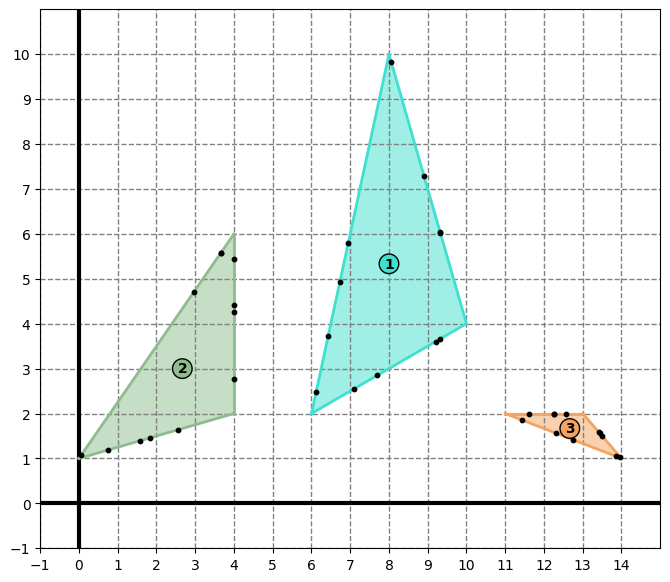

Next, let's take some sample paths from the points to the x-axis. Since all of our paths will always be straight lines and point towards the x-axis, we only need to use the bottom half of possible angle choices (bottom two quadrants between π and 2π). Here's the code that will help us do that:

In [ ]:
def generate_rays(self):
    for center in self.points:
        associated_segment = None
        for segment in self.line_segments:
            A, B = np.array(segment[0]), np.array(segment[1])
            AB = B - A
            AC = np.array(center) - A
            cross_product = np.cross(AB, AC)
            if np.isclose(cross_product, 0):
                t = np.dot(AC, AB) / np.dot(AB, AB)
                if 0 <= t <= 1:
                    associated_segment = segment
                    break

        angle_spacing = np.pi / NUM_RAYS
        angles = np.linspace(-np.pi, -2 * np.pi, NUM_RAYS, endpoint=False)
        rotation_angle = 180 - (angle_spacing / np.pi) * 180 / 2
        angles += np.radians(rotation_angle)

        for angle in angles:
            direction = np.array([np.cos(angle), np.sin(angle)])
            if direction[1] != 0:
                if associated_segment[0][1] != associated_segment[1][1]:
                    t = -center[1] / direction[1]
                    x_intersect = center[0] + t * direction[0]
                    end_point = [x_intersect, 0]
                    ray = Ray(center.tolist(), end_point, associated_segment)
                    self.rays.append(ray)

def plot_rays(self):
    for ray in self.rays:
        ray.plot()

And here's what it gets us:

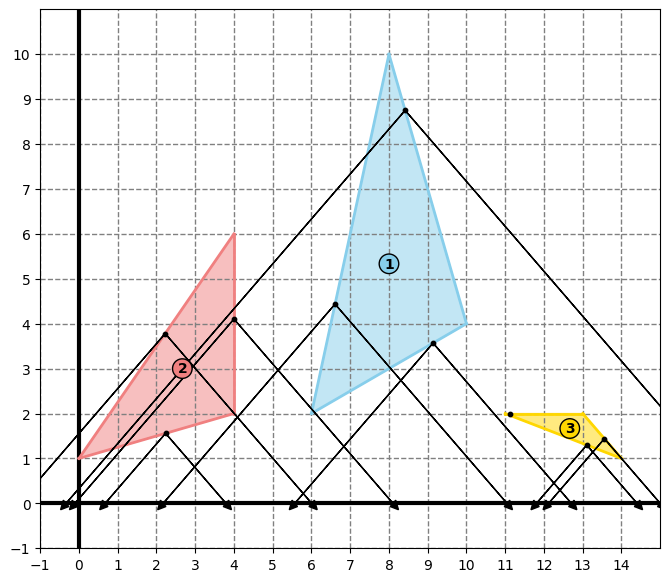

For clarity, I've reduced the number of points per side to 1 and number of rays per point to 2, but this isn't very accurate. To increase our accuracy, let's increase the number of data points we sample from as well as the number of paths we check.

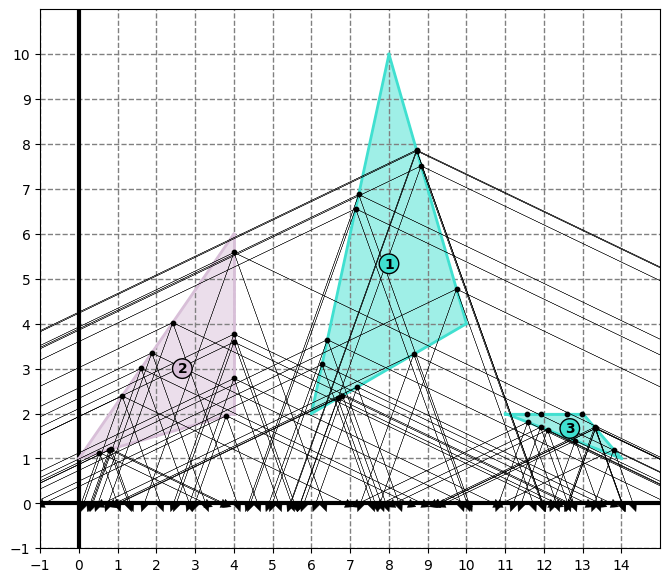

A little cluttered, but not without cause. Notice that we don't draw any paths for horizontal sides (sides parallel to the x-axis) that have another point beneath them. That is because there is no way to draw a straight line from anywhere on these line segments to the x-axis without intersecting at least one other side (from the same triangle). **Thus, we can save some computational effort by ignoring these points altogether.** Now, we can check our new data points and see which result in valid paths.

In [ ]:
def ccw(A, B, C):
    return (C[1] - A[1]) * (B[0] - A[0]) > (B[1] - A[1]) * (C[0] - A[0])


def segment_intersection(segment1, segment2):
    A, B = segment1
    C, D = segment2
    return ccw(A, C, D) != ccw(B, C, D) and ccw(A, B, C) != ccw(A, B, D)


def reachable_rays(triangle):
    triangle.safety_checks()
    reachable_distance = 0
    has_limegreen_ray = False
    for ray in reversed(triangle.rays):
        for segment in all_segments:
            if ray.lies_on(segment):
                continue
            elif not ray.lies_on(segment) and ray.intersects_with(segment):
                ray.color = "red"
                break
            else:
                ray.color = "limegreen"
                has_limegreen_ray = True
                if segment not in triangle.reachable_sides and segment in triangle.line_segments and segment[0][1] != segment[1][1]:
                    triangle.reachable_sides.append(segment)

    for segment in triangle.reachable_sides:
        reachable_distance += np.linalg.norm(np.array(segment[0]) - np.array(segment[1]))
    return reachable_distance

This code utilizes cross products to check the orientation of two line segments (here, the triangle side and the path we've drawn) with respect to each other. By checking the entire path, one by one, we effectively adopt a strategy analogous to depth-first search, which is useful as it allows us to try every possible option. Here's a better visual of which paths are valid (in green):

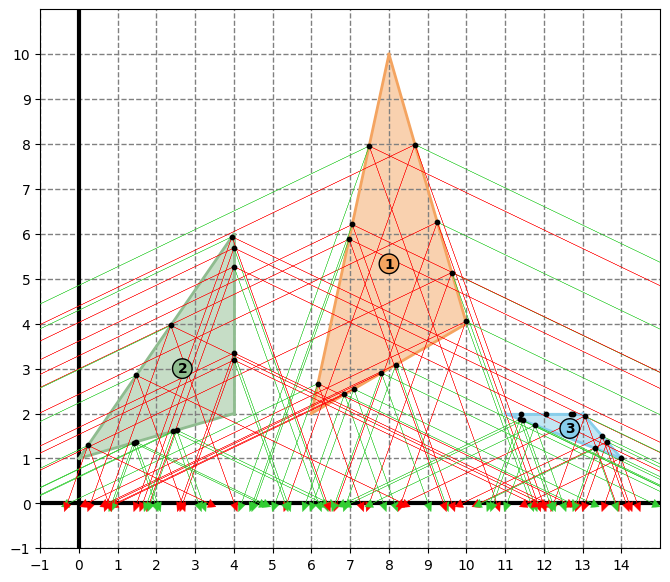

Now we're really getting somewhere. Let's put it all together, and then calculate the length of the unreachable sides (2).

(2) Actually, we're going to be performing a different calculation. In our approach, we assume every path we've drawn to be invalid, and only consider it to be valid after it's been checked. This allows us to say that there is at least one path for a line to be drawn between a triangle's side and the x-axis. Because of this, we'll instead calculate the sum of the lengths of all the validated sides, and then subtract that sum from the perimeter of the triangle. The **difference** will be the **length of the unreachable sides**. This is the same as with probability--the probability of an event happening is the same as 1 - the complement of that event.

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import random

PI = np.pi
POINT_SIZE = 10

class Ray:
    def __init__(self, start, end, line_segment):
        self.start = start
        self.end = end
        self.color = "limegreen"
        self.line_segment = line_segment

    def lies_on(self, segment):
        return (
            segment[0] == self.line_segment[0] and segment[1] == self.line_segment[1]
        ) or (segment[0] == self.line_segment[1] and segment[1] == self.line_segment[0])

    def intersects_with(self, segment):
        return segment_intersection([self.start, self.end], segment)

    def plot(self):
        plt.arrow(
            self.start[0],
            self.start[1],
            self.end[0] - self.start[0],
            self.end[1] - self.start[1],
            head_width=0.2,
            head_length=0.2,
            fc=self.color,
            ec=self.color,
            linewidth=1 / NUM_POINTS,
            zorder=4,
        )

class Triangle:
    def __init__(self, vertices, triangle_number):
        self.vertices = vertices
        self.points = []
        self.rays = []
        self.line_segments = []
        self.reachable_sides = []
        self.perimeter = None
        self.triangle_number = triangle_number

        self.get_line_segments()
        self.get_perimeter()

    def get_line_segments(self):
        for i in range(len(self.vertices)):
            segment = [self.vertices[i], self.vertices[(i + 1) % len(self.vertices)]]
            self.line_segments.append(segment)
            all_segments.append(segment)

    def get_perimeter(self):
        perimeter = 0
        for segment in self.line_segments:
            perimeter += np.linalg.norm(np.array(segment[0]) - np.array(segment[1]))
        self.perimeter = perimeter

    def plot(self):
        colors = [
            "lightcoral",
            "lightsalmon",
            "sandybrown",
            "gold",
            "darkseagreen",
            "turquoise",
            "skyblue",
            "mediumpurple",
            "thistle",
        ]
        color = random.choice(colors)
        a, b, c = (
            np.array(self.vertices[0]),
            np.array(self.vertices[1]),
            np.array(self.vertices[2]),
        )
        t = np.linspace(0, 1, 100)
        line_AB = np.outer(1 - t, a) + np.outer(t, b)
        line_BC = np.outer(1 - t, b) + np.outer(t, c)
        line_CA = np.outer(1 - t, c) + np.outer(t, a)
        plt.fill([a[0], b[0], c[0]], [a[1], b[1], c[1]], color=color, alpha=0.5)
        plt.plot(line_AB[:, 0], line_AB[:, 1], color=color, linewidth=2)
        plt.plot(line_BC[:, 0], line_BC[:, 1], color=color, linewidth=2)
        plt.plot(line_CA[:, 0], line_CA[:, 1], color=color, linewidth=2)

        centroid = np.mean(self.vertices, axis=0)

        plt.text(
            centroid[0],
            centroid[1],
            str(self.triangle_number),
            color="black",
            fontsize=10,
            fontweight="bold",
            ha="center",
            va="center",
            bbox=dict(boxstyle="circle,pad=0.2", facecolor=color, edgecolor="black"),
            zorder=6,
        )

    def sample_points(self):
        for i in range(len(self.vertices)):
            start = np.array(self.vertices[i])
            end = np.array(self.vertices[(i + 1) % len(self.vertices)])
            t_values = np.random.uniform(0, 1, NUM_POINTS)
            self.points.extend([(1 - t) * start + t * end for t in t_values])

    def plot_points(self):
        for point in self.points:
            plt.scatter(point[0], point[1], color="black", s=POINT_SIZE, zorder=5)

    def generate_rays(self):
        for center in self.points:
            associated_segment = None
            for segment in self.line_segments:
                A, B = np.array(segment[0]), np.array(segment[1])
                AB = B - A
                AC = np.array(center) - A
                cross_product = np.cross(AB, AC)
                if np.isclose(cross_product, 0):
                    t = np.dot(AC, AB) / np.dot(AB, AB)
                    if 0 <= t <= 1:
                        associated_segment = segment
                        break

            angle_spacing = np.pi / NUM_RAYS
            angles = np.linspace(-np.pi, -2 * np.pi, NUM_RAYS, endpoint=False)
            rotation_angle = 180 - (angle_spacing / np.pi) * 180 / 2
            angles += np.radians(rotation_angle)

            for angle in angles:
                direction = np.array([np.cos(angle), np.sin(angle)])
                if direction[1] != 0:
                    if associated_segment[0][1] != associated_segment[1][1]:
                        t = -center[1] / direction[1]
                        x_intersect = center[0] + t * direction[0]
                        end_point = [x_intersect, 0]
                        ray = Ray(center.tolist(), end_point, associated_segment)
                        self.rays.append(ray)

    def plot_rays(self):
        for ray in self.rays:
            ray.plot()

    def safety_checks(self):
        for side in self.line_segments:
            if side not in self.reachable_sides:
              if side[0][1] == side[1][1] and side[0][1] == 0:
                self.reachable_sides.append(side)

def graph(*commands):
    plt.figure(figsize=(8, 7))
    plt.axhline(0, color="black", linewidth=3)
    plt.axvline(0, color="black", linewidth=3)
    plt.grid(color="gray", linestyle="--", linewidth=1)
    plt.xticks(np.arange(custom_axis[0], custom_axis[1], 1))
    plt.yticks(np.arange(custom_axis[2], custom_axis[3], 1))
    plt.axis(custom_axis)
    for func in commands:
        func()
    plt.show()

def ccw(A, B, C):
    return (C[1] - A[1]) * (B[0] - A[0]) > (B[1] - A[1]) * (C[0] - A[0])

def segment_intersection(segment1, segment2):
    A, B = segment1
    C, D = segment2
    return ccw(A, C, D) != ccw(B, C, D) and ccw(A, B, C) != ccw(A, B, D)

def reachable_rays(triangle):
    triangle.safety_checks()
    reachable_distance = 0
    has_limegreen_ray = False
    for ray in reversed(triangle.rays):
        for segment in all_segments:
            if ray.lies_on(segment):
                continue
            elif not ray.lies_on(segment) and ray.intersects_with(segment):
                ray.color = "red"
                break
            else:
                ray.color = "limegreen"
                has_limegreen_ray = True
                if segment not in triangle.reachable_sides and segment in triangle.line_segments and segment[0][1] != segment[1][1]:
                    triangle.reachable_sides.append(segment)

    for segment in triangle.reachable_sides:
        reachable_distance += np.linalg.norm(np.array(segment[0]) - np.array(segment[1]))
    return reachable_distance

Feel free to play around with the `NUM_POINTS` and `NUM_RAYS` values and observe the effect it has on run time & accuracy.

Unreachable distance for triangle 1: 0.0
Unreachable distance for triangle 2: 0.0
Unreachable distance for triangle 3: 2.0



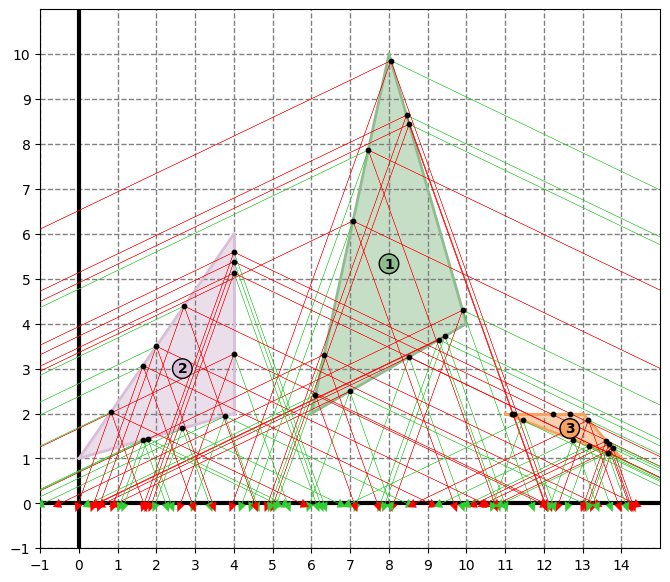

In [46]:
#@title { vertical-output: true}

NUM_POINTS = 4
NUM_RAYS = 4

all_segments = []
unreachable_distance = 0
custom_axis = (-1, 15, -1, 11)

triangles = [
              Triangle([[8, 10], [10, 4], [6, 2]], 1),
              Triangle([[4, 6], [4, 2], [0, 1]], 2),
              Triangle([[13, 2], [14, 1], [11, 2]], 3)
            ]

for triangle in triangles:
  unreachable_distance += triangle.perimeter

  triangle.sample_points()
  triangle.generate_rays()

  unreachable_distance -= reachable_rays(triangle)
  print(f"Unreachable distance for triangle {triangles.index(triangle) + 1}: {unreachable_distance}")
  unreachable_distance = 0

print()

graph(
  lambda: [triangle.plot() for triangle in triangles],
  lambda: [triangle.plot_points() for triangle in triangles],
  lambda: [triangle.plot_rays() for triangle in triangles]
)

Now, let's put it to the test: using the given test cases from the problem statement, we can determine the lengths of the unreachable sides of the five triangles.

Unreachable distance for triangle 1: 0.0
Unreachable distance for triangle 2: 1.9999999999999998
Unreachable distance for triangle 3: 0.0
Unreachable distance for triangle 4: 4.000000000000001
Unreachable distance for triangle 5: 0.0



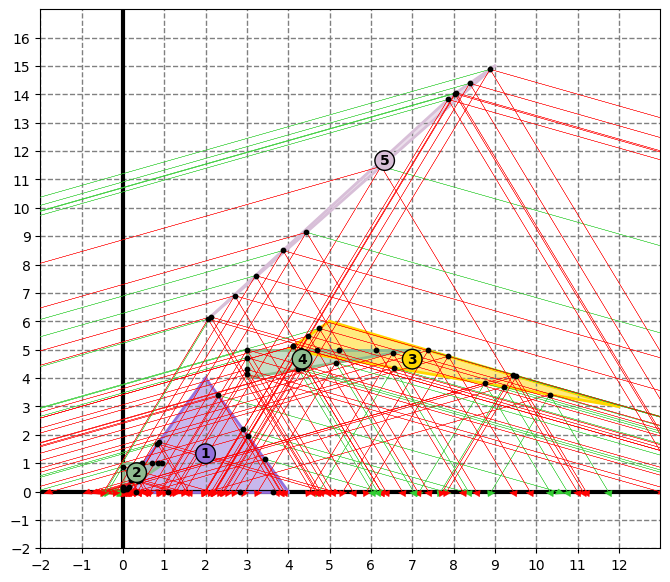

In [44]:
#@title { vertical-output: true}

NUM_POINTS = 4
NUM_RAYS = 4

all_segments = []
unreachable_distance = 0
custom_axis = (-2, 13, -2, 17)

triangles = [
              Triangle([[0, 0], [4, 0], [2, 4]], 1),
              Triangle([[0, 1], [1, 1], [0, 0]], 2),
              Triangle([[12, 3], [4, 5], [5, 6]], 3),
              Triangle([[3, 5], [3, 4], [7, 5]], 4),
              Triangle([[2, 6], [9, 15], [8, 14]], 5)
            ]

for triangle in triangles:
  unreachable_distance += triangle.perimeter

  triangle.sample_points()
  triangle.generate_rays()

  unreachable_distance -= reachable_rays(triangle)
  triangle.safety_checks()
  print(f"Unreachable distance for triangle {triangles.index(triangle) + 1}: {unreachable_distance}")
  unreachable_distance = 0

print()

graph(
  lambda: [triangle.plot() for triangle in triangles],
  lambda: [triangle.plot_points() for triangle in triangles],
  lambda: [triangle.plot_rays() for triangle in triangles]
)

As we can see, the **sum of the length of all unreachable parts is 6**. We get 2 from Triangle 2 (top and diagonal sides) and 4 from Triangle 4 (top side).